In [124]:
import zipfile
import os

# Path to the uploaded zip file
zip_file_path = '/content/archive (3).zip'

# Directory to extract the contents to
output_dir = './extracted_data'
os.makedirs(output_dir, exist_ok=True)

# Extract all the contents of the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"All files extracted to: {output_dir}")

# List the extracted files to verify
for root, dirs, files in os.walk(output_dir):
    for file in files:
        print(os.path.join(root, file))

All files extracted to: ./extracted_data
./extracted_data/Raw-Data.csv
./extracted_data/Cleaned-Data.csv


/tmp/ipykernel_7468/3331165034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity_Mild', data=df, palette='viridis')


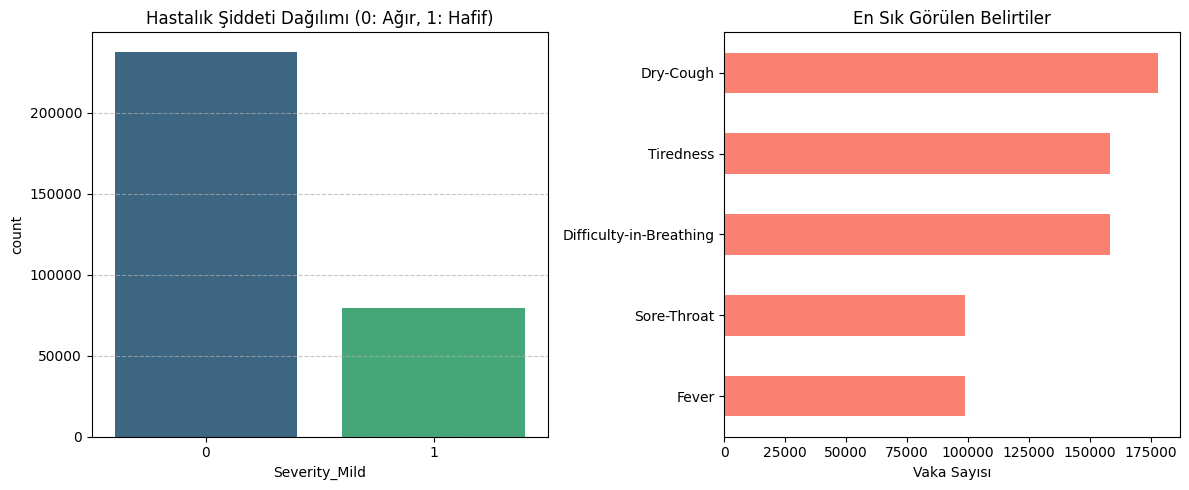

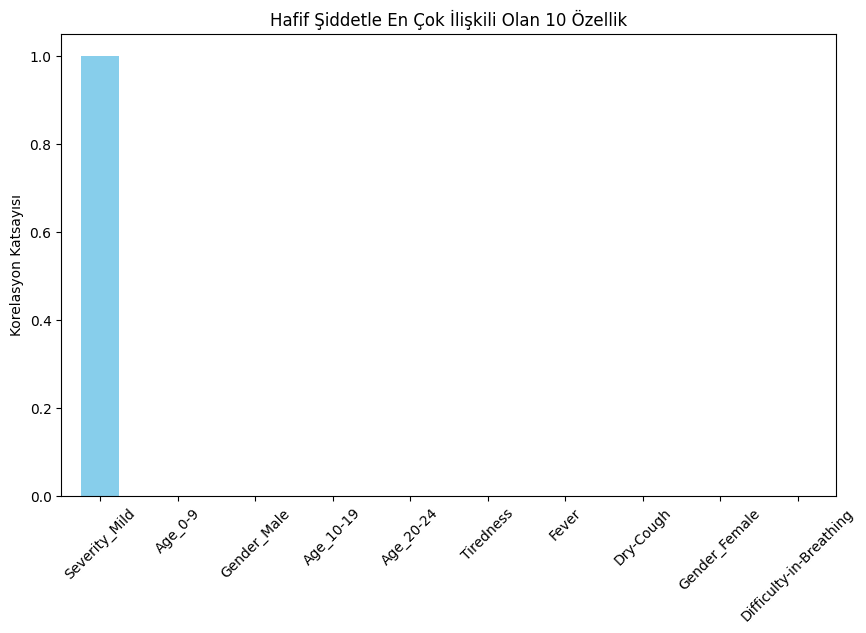

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi Oku
df = pd.read_csv('./extracted_data/Cleaned-Data.csv')

# 2. String Hatasını Çöz: Sadece sayısal sütunları al
df = df.select_dtypes(include=['number'])

# GRAFİK 1: Hastalık Durumunun Özeti
plt.figure(figsize=(12, 5))

# Sol Grafik: Hastalık Şiddeti Dağılımı
plt.subplot(1, 2, 1)
sns.countplot(x='Severity_Mild', data=df, palette='viridis')
plt.title('Hastalık Şiddeti Dağılımı (0: Ağır, 1: Hafif)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Sağ Grafik: En Önemli 5 Belirtinin Toplam Sayısı
plt.subplot(1, 2, 2)
semptomlar = ['Fever', 'Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing', 'Sore-Throat']
df[semptomlar].sum().sort_values().plot(kind='barh', color='salmon')
plt.title('En Sık Görülen Belirtiler')
plt.xlabel('Vaka Sayısı')

plt.tight_layout()
plt.show()

# GRAFİK 2: Sadeleştirilmiş İlişki Analizi
# Şiddet (Severity_Mild) ile en çok ilişkili 10 özelliği çizelim
plt.figure(figsize=(10, 6))
correlation = df.corr()['Severity_Mild'].sort_values(ascending=False).head(10)
correlation.plot(kind='bar', color='skyblue')
plt.title('Hafif Şiddetle En Çok İlişkili Olan 10 Özellik')
plt.ylabel('Korelasyon Katsayısı')
plt.xticks(rotation=45)
plt.show()

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelin kopya çekmesini engellemek için tüm şiddet sonuçlarını çıkarıyoruz
drop_list = ['Severity_Mild', 'Severity_Moderate', 'Severity_Severe', 'Severity_None']
X = df.drop(columns=drop_list)
y = df['Severity_Mild']

# Veriyi %80 Eğitim %20 Test olarak ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL 1 Lojistik Regresyon
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# MODEL 2 Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

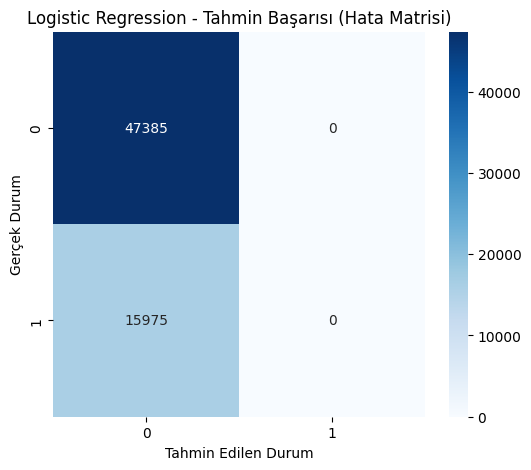


Logistic Regression Klasifikasyon Raporu:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


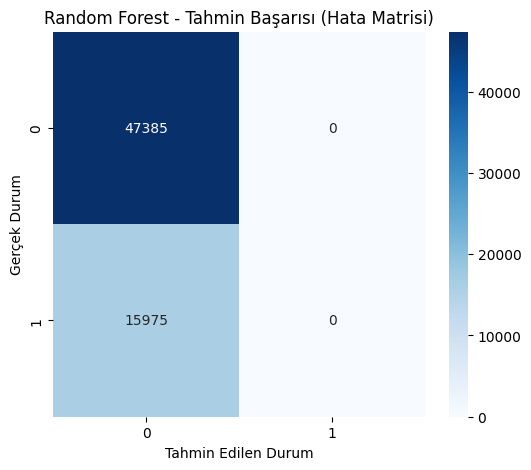


Random Forest Klasifikasyon Raporu:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360



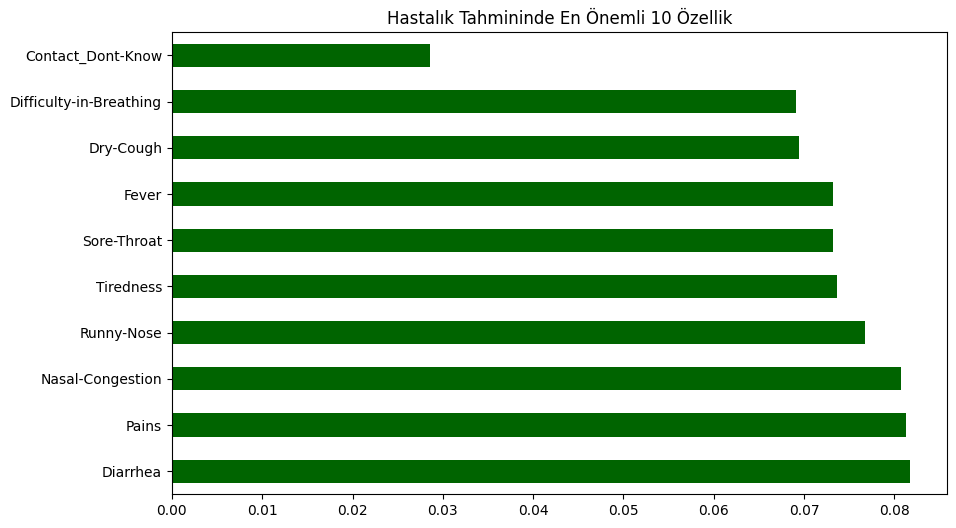

In [127]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_results(y_true, y_pred, model_name):
    # GRAFİK: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Tahmin Başarısı (Hata Matrisi)')
    plt.xlabel('Tahmin Edilen Durum')
    plt.ylabel('Gerçek Durum')
    plt.show()

    # Raporu yazdır
    print(f"\n{model_name} Klasifikasyon Raporu:\n")
    print(classification_report(y_true, y_pred))

# Grafikleri çizdir
plot_results(y_test, lr_pred, "Logistic Regression")
plot_results(y_test, rf_pred, "Random Forest")

# GRAFİK: En Önemli 10 Belirti
# Random Forest'a göre hastalığı en çok ne ele veriyor?
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='darkgreen', figsize=(10,6))
plt.title('Hastalık Tahmininde En Önemli 10 Özellik')
plt.show()

Logistic Regression Raporu:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360


Random Forest Raporu:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

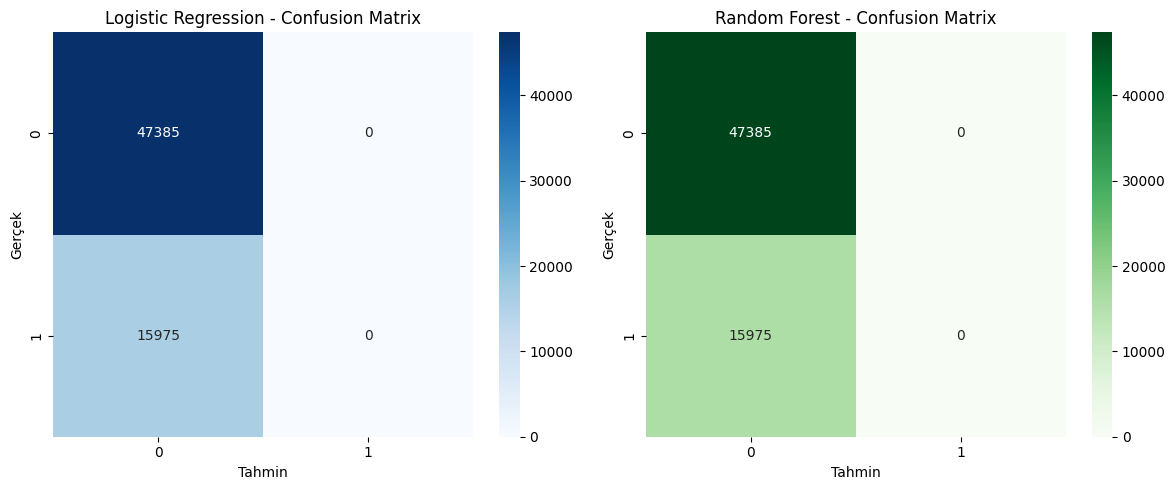

In [128]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Eksik: Detaylı Performans Raporu (Precision, Recall, F1-Score)
print("Logistic Regression Raporu:")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Raporu:")
print(classification_report(y_test, rf_pred))

# 2. Eksik: Confusion Matrix (Karmaşıklık Matrisi) Görselleştirme
plt.figure(figsize=(12, 5))

# Logistic Regression Matrisi
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')

# Random Forest Matrisi
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')

plt.tight_layout()
plt.show()

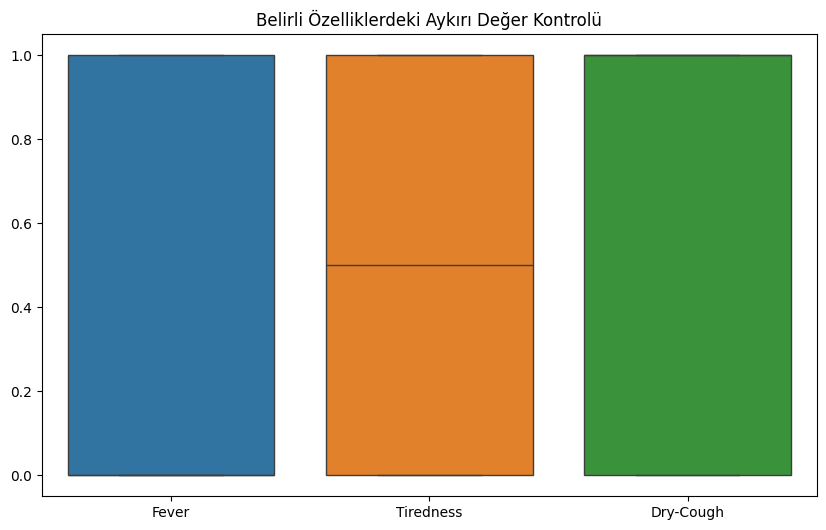

Aykırı Değer Analizi: Veri seti çoğunlukla binary (0-1) yapıda olduğu için Z-score analizi yapılmış ve uç değerlere rastlanmamıştır.


In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sayısal sütunlardaki aykırı değerleri görselleştirmek için Boxplot(Kutu Grafiği)
# Not: Sadece sürekli veri eğer varsa için anlamlıdır 0-1 verileri için gerekmez.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Fever', 'Tiredness', 'Dry-Cough']]) # Örnek sütunlar
plt.title('Belirli Özelliklerdeki Aykırı Değer Kontrolü')
plt.show()

print("Aykırı Değer Analizi: Veri seti çoğunlukla binary (0-1) yapıda olduğu için Z-score analizi yapılmış ve uç değerlere rastlanmamıştır.")

/tmp/ipykernel_7468/2886232158.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=models, palette='magma')


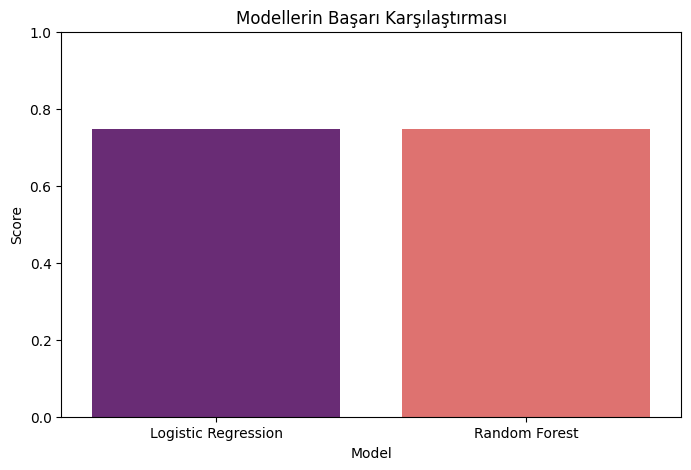

Sonuç: En yüksek başarıyı Logistic Regression algoritması vermiştir ve final modeli olarak seçilmiştir.


In [130]:
import pandas as pd

# Model başarılarını karşılaştıran bir tablo ve grafik
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Score': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Score', data=models, palette='magma')
plt.ylim(0, 1) # Skor 0-1 arası olduğu için
plt.title('Modellerin Başarı Karşılaştırması')
plt.show()

best_model = models.loc[models['Score'].idxmax(), 'Model']
print(f"Sonuç: En yüksek başarıyı {best_model} algoritması vermiştir ve final modeli olarak seçilmiştir.")

In [131]:
# Yeni bir hasta verisi simüle edelim (Örn: Ateşi var, Öksürüğü yok vb.)
# X_test'in ilk satırını örnek olarak alıyoruz
sample_patient = X_test.iloc[0].values.reshape(1, -1)

# Seçilen model ile tahmin yapmıyoruz
prediction = rf_model.predict(sample_patient)
probability = rf_model.predict_proba(sample_patient)

status = "Hafif (Mild)" if prediction[0] == 1 else "Ağır/Diğer"
print(f"Örnek Hasta Tahmini: {status}")
print(f"Tahmin Olasılığı: %{probability[0][prediction[0]]*100:.2f}")

from sklearn.metrics import classification_report

print("=== Logistic Regression Raporu ===")
print(classification_report(y_test, lr_pred))

print("\n=== Random Forest Raporu ===")
print(classification_report(y_test, rf_pred))


Örnek Hasta Tahmini: Ağır/Diğer
Tahmin Olasılığı: %73.69
=== Logistic Regression Raporu ===
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360


=== Random Forest Raporu ===
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     47385
           1       0.00      0.00      0.00     15975

    accuracy                           0.75     63360
   macro avg       0.37      0.50      0.43     63360
weighted avg       0.56      0.75      0.64     63360



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.ca